In [3]:
import torch
import pandas as pd
import numpy as np
import torchvision.transforms as Tr
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO
import napari
from tkinter import filedialog as fd
from scipy.optimize import curve_fit
from matplotlib import pyplot as plt
import nibabel as nib
import matplotlib as mpl
from skimage.exposure import match_histograms
from nilearn import image
from nilearn import plotting
from scipy.ndimage import gaussian_filter
import math
import matplotlib.patches as patches

In [22]:
def mask(seg, val):
    #To extract individual tissue from segmentation nib file
    binary_mask = np.where(seg == val, 1, 0) # Integer Mask
    return binary_mask

#dataset 1
"""
seg_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pveseg.nii.gz"
csf_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pve_0.nii.gz")
gm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pve_1.nii.gz")
wm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain_pve_2.nii.gz")
img_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/Datasets/ExBox3/T1_brain.nii.gz")
seg = nib.load(seg_loc).get_fdata()
"""

#dataset 2
"""
seg_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pveseg.nii.gz"
csf_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_0.nii.gz")
gm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_1.nii.gz")
wm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_2.nii.gz")
img_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_restore.nii.gz") #Can use either bias corrected or brain extracted version here
seg = nib.load(seg_loc).get_fdata()
"""


#IXI sample 102
'''
seg_loc = "/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Hulf_Synth/Data/ixi/T1/102/hf/fast_pveseg.nii.gz"
csf_nib = nib.load("./Data/ixi/T1/102/hf/fast_pve_0.nii.gz")
gm_nib = nib.load("./Data/ixi/T1/102/hf/fast_pve_1.nii.gz")
wm_nib = nib.load("./Data/ixi/T1/102/hf/fast_pve_2.nii.gz")
img_nib = nib.load("./Data/ixi/T1/102/hf/fast_restore.nii.gz") #Can use either bias corrected or brain extracted version here
seg = nib.load(seg_loc).get_fdata()
'''

# Validation Data

seg_loc = "./Data/validation_data/ulf/fast_seg.nii.gz"
csf_nib = nib.load("./Data/validation_data/ulf/fast_pve_0.nii.gz")
gm_nib = nib.load("./Data/validation_data/ulf/fast_pve_1.nii.gz")
wm_nib = nib.load("./Data/validation_data/ulf/fast_pve_2.nii.gz")
img_nib = nib.load("./Data/validation_data/ulf/fast_restore.nii.gz") #Can use either bias corrected or brain extracted version here
seg = nib.load(seg_loc).get_fdata()





#Extracting tissues
csf_masked = mask(seg,1)
gm_masked = mask(seg,2)
wm_masked = mask(seg,3)

csf = csf_masked  * img_nib.get_fdata() #* csf_nib.get_fdata()
gm = gm_masked  * img_nib.get_fdata() #* gm_nib.get_fdata()
wm = wm_masked  * img_nib.get_fdata() #* wm_nib.get_fdata()
hf = hf_img = csf + gm + wm

In [23]:
csf.shape

(224, 224, 160)

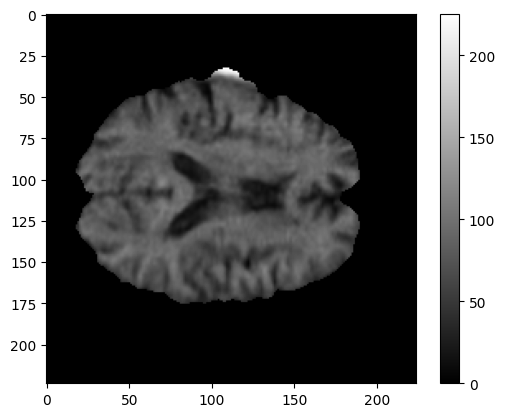

In [28]:
%matplotlib inline
slice_num = 81
plt.imshow(img_nib.get_fdata()[:,:,slice_num],cmap='gray')
plt.colorbar()
# plt.show()

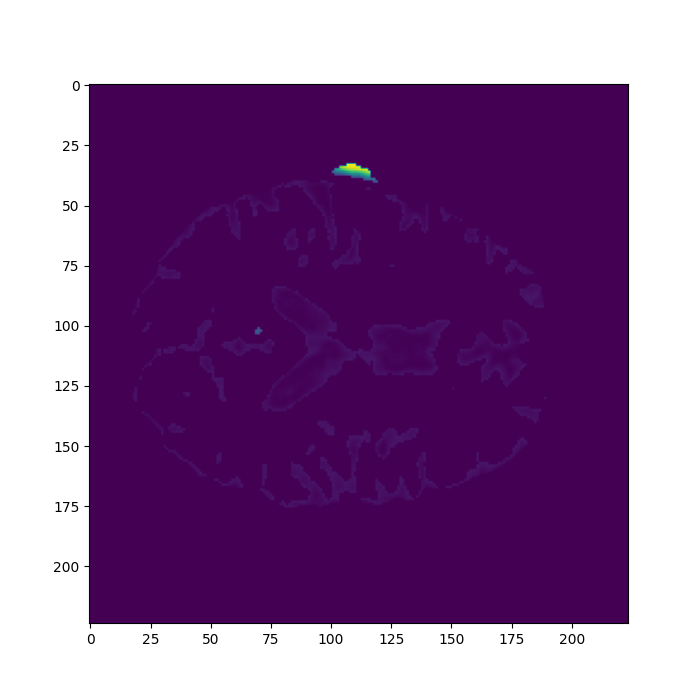

In [32]:
%matplotlib ipympl
# %matplotlib inline

import matplotlib.cbook as cbook
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from mpl_interactions import image_segmenter


im = Image.fromarray((csf*img_nib.get_fdata())[:,:,slice_num])
segmenter = image_segmenter(im, mask_colors="red", mask_alpha=0.99, figsize=(7, 7))
display(segmenter,colormaps='gray',colorbar=segmenter)



In [ ]:
#dataset = 1 #csf (119,82) (128,82) -> (119,85) (128,85) #gm (123, 77) (126, 79) -> (133,70) (135, 74)
#dataset = 2 #wm(135,106) (142,106) -> (135,103) (142, 103) #gm (43, 50) (47,50) -> (43, 46) (47, 46), #csf (64, 101) (83,101) -> (64,98) (83,98)

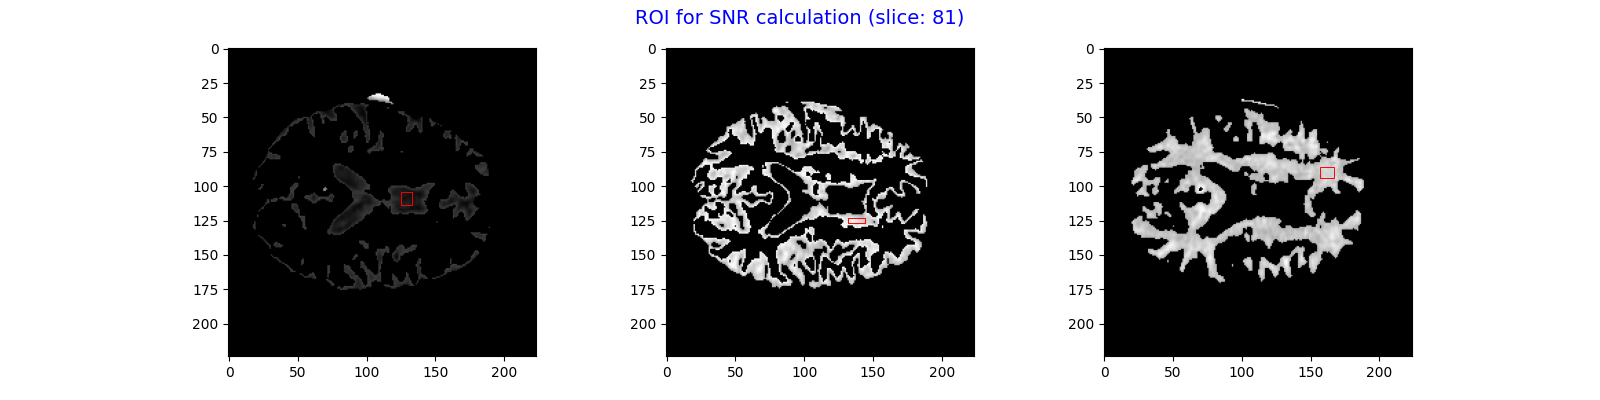

In [39]:
# %matplotlib inline
# %matplotlib ipympl

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
im1 = axs[0].imshow((csf)[:,:,slice_num],cmap='gray')# ,vmax = 1000)
im2 = axs[1].imshow((gm)[:,:,slice_num],cmap='gray')#,vmax = 800)
im3 = axs[2].imshow((wm)[:,:,slice_num],cmap='gray')#,vmax = 600)


# rect3 = patches.Rectangle((55, 69), 5, 3, linewidth=1, edgecolor='r', facecolor='none') #ms 
rect0 = patches.Rectangle((125, 104), 8, 10, linewidth=0.7, edgecolor='r', facecolor='none') #csf 
rect1 = patches.Rectangle((132, 123), 12, 4, linewidth=0.7, edgecolor='r', facecolor='none') #gm 
rect2 = patches.Rectangle((157, 86), 10, 8, linewidth=0.7, edgecolor='r', facecolor='none') #wm

axs[0].add_patch(rect0)
axs[1].add_patch(rect1)
axs[2].add_patch(rect2)
# axs[3].add_patch(rect3)



fig.suptitle('ROI for SNR calculation'+ ' (slice: ' + str(slice_num) + ')', fontsize=14,color='blue')
plt.show()

In [54]:
#dataset = 1
# csf[82:86,119:128,95]
# gm[76:80, 123:128,95]
# wm[99:109,145:155,95]
# print(wm[99:109,145:155,95].mean(), gm[76:80, 123:128,95].mean(), csf[82:86,119:128,95].mean())

#dataset = 2
# print((wm)[105:110, 132:142, 95].mean(), (gm)[45:48,43:48,95].mean(), (csf)[96:101,70:80,95].mean())

329.27 188.25 64.0


Check if there are any pixels where signal intensity = 0

In [47]:
#val data
# print(wm[86:94, 157:167, slice_num])
# print(gm[123:127, 132:144, slice_num])

# print(csf[104:114, 125:133, slice_num])
print((csf)[104:114, 125:133, slice_num].mean(), gm[123:127, 132:144, slice_num].mean(), wm[86:94, 157:167, slice_num].mean())


21.47027349472046 69.7281665802002 93.73921642303466


In [55]:
# img_nib.get_fdata()[99:109,145:155,95][wm_nib.get_fdata()[99:109,145:155,95]>0.9]
# (img_nib.get_fdata()[86:94, 157:167, slice_num][wm_nib.get_fdata()[86:94, 157:167, slice_num]>0.9])
(img_nib.get_fdata()[123:127, 132:144, slice_num][gm_nib.get_fdata()[123:127, 132:144, slice_num]>0.9])

array([68.84153748, 71.60861206, 73.38883209, 73.23817444, 71.17004395,
       69.11433411, 67.06453705, 65.01038361, 62.95951843, 61.87623978,
       60.80706787, 59.74394226, 69.52147675, 72.27701569, 73.75850677,
       71.70840454, 71.57273865, 67.61521149, 65.56929779, 67.33174896,
       64.36454773, 61.41025925, 71.17329407, 72.95513916, 72.38793945,
       72.25273895, 70.20787048, 68.16590881, 68.02817535, 66.01441193,
       64.00967407, 71.86936951, 72.12378693, 71.04264069, 69.9536972 ,
       68.86408234, 67.78469086, 66.71845245, 65.65761566])

In [105]:
'''
#taking mean of only those samples which are 90% probabilistic
csf_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_0.nii.gz")
gm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_1.nii.gz")
wm_nib = nib.load("/Users/pi58/Library/CloudStorage/Box-Box/PhD/MPhil/Projects/Contrast_Estimation/ExBox3/data_2/structural_brain_pve_2.nii.gz")


wm_roi_pixels = img_nib.get_fdata()[105:110, 132:142, 95][wm_nib.get_fdata()[105:110, 132:142, 95]>0.9]
gm_roi_pixels = img_nib.get_fdata()[45:48,43:48,95][gm_nib.get_fdata()[45:48,43:48,95]>0.9]
csf_roi_pixels = img_nib.get_fdata()[96:101,70:80,95][csf_nib.get_fdata()[96:101,70:80,95]>0.9]

print(csf_roi_pixels.mean())
'''

Noise
- Loading raw image and computing BG nosie

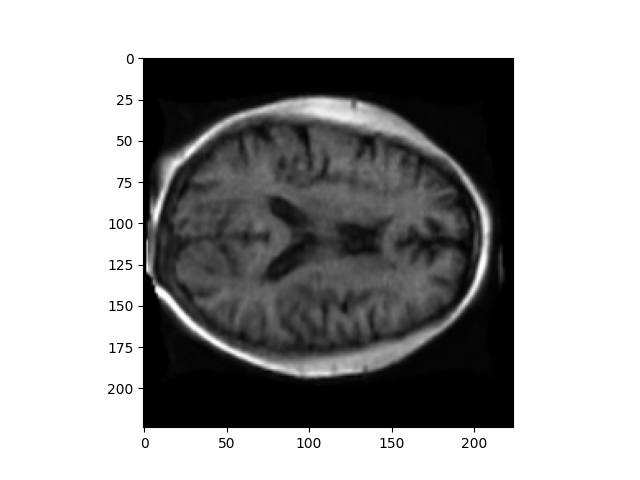

In [63]:
%matplotlib ipympl
# %matplotlib inline

noise = nib.load("./Data/validation_data/ulf/raw.nii.gz")
plt.imshow(noise.get_fdata()[:,:,slice_num], cmap='gray')
plt.show()


In [69]:



std_bg = noise.get_fdata()[:,:,slice_num][168:182, 20:28, ].std() #region-1 #Validation data
print(std_bg)
std_bg = noise.get_fdata()[:,:,slice_num][28:42, 20:30, ].std() #region-1 #Validation data
print(std_bg)
# noise.get_fdata()[:,163,:][50:60,124:138, ].std() #region-2


2.6625113777662426
2.0706279240848655


In [ ]:
#Noise for dataset = 2
noise = nib.load("./data_2/structural.nii.gz")
print("BG Noise in different regions :", noise.get_fdata()[:20,:20,95].std(), noise.get_fdata()[150:170,150:170,95].std(), noise.get_fdata()[155:,:25,95].std(), noise.get_fdata()[:25,150:170,95].std()) #Mean of all 4 regions in background
std_bg = noise.get_fdata()[:20,:20,95].std() #Background Noise extracted manually

In [104]:
std_bg

5.867293229716557